## Introduction

The objective of this notebook is to **compare several simple long-only investment strategies:**
1. Equity buy-and-hold
2. Equity–bond buy-and-hold
3. Volatility-driven equity-to-bond switching
4. Drawdown-driven equity-to-bond switching
5. Drawdown-driven & volatility-driven equity-to-bond switching

## Import librairies

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

## Custom function

In [43]:
def compute_metrics(price_ts, title):

    dd = price_ts / price_ts.expanding().max() - 1
    max_dd = dd.min()
    print(f'max drawdown: {max_dd:.2%}')
    
    win_loss_ratio = price_ts.diff().clip(lower=0).sum() / -price_ts.diff().clip(upper=0).sum()
    print(f'win/loss ratio: {win_loss_ratio:.2f}')

    sharpe = (price_ts.pct_change().mean() * 252) / (price_ts.pct_change().std() * np.sqrt(252))
    print(f'sharpe ratio: {sharpe:.2f}')

    total_performance = price_ts.iloc[-1] / price_ts.iloc[0]
    n = ((price_ts.index[-1]-price_ts.index[0]).days / 365)
    x = total_performance**(1/n) -1
    print(f'annualized return: {x:.2%}')

    annual_returns = price_ts.groupby(price_ts.index.year).last().pct_change()

    multiplier = -0.55 / max_dd
    #multiplier = min([2, multiplier])
    print(f'multiplier: {multiplier:.2f}')
    annual_returns_scaled = annual_returns * multiplier
    x_scaled = annual_returns_scaled.add(1).prod()**(1/n) - 1
    print(f'annualized return scaled: {x_scaled:.2%}')

    plt.figure(figsize=(13, 4))
    sns.lineplot(data=price_ts)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 4))
    sns.barplot(x=annual_returns.index.astype(str), y=annual_returns.values)
    plt.title(f'Annual Returns')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 4))
    sns.barplot(x=annual_returns_scaled.index.astype(str), y=annual_returns_scaled.values)
    plt.title(f'Annual Returns Scaled')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    

## Inputs

In [44]:
eq_asset = 'SPY'
bond_asset = 'IBGS.MI'
vol_threshold_buy = 0.8
vol_threshold_sell = 0.04
vol_window = 5
dd_threshold_buy = 0.60
dd_threshold_sell = 1.0


## Script

In [45]:
df_eq = pd.read_csv(f'data/{eq_asset}.csv', index_col=0, parse_dates=True)
df_bond = pd.read_csv(f'data/{bond_asset}.csv', index_col=0, parse_dates=True)
df_bond = df_eq * 0 + 0.01/365
df_bond = df_bond.add(1).cumprod()
df_price = pd.concat([df_eq.price, df_bond.price], axis=1, keys=['equity', 'bond']).dropna()


## 1. Equity buy-and-hold

max drawdown: -55.19%
win/loss ratio: 1.13
sharpe ratio: 0.52
annualized return: 8.45%
multiplier: 1.00
annualized return scaled: 7.68%


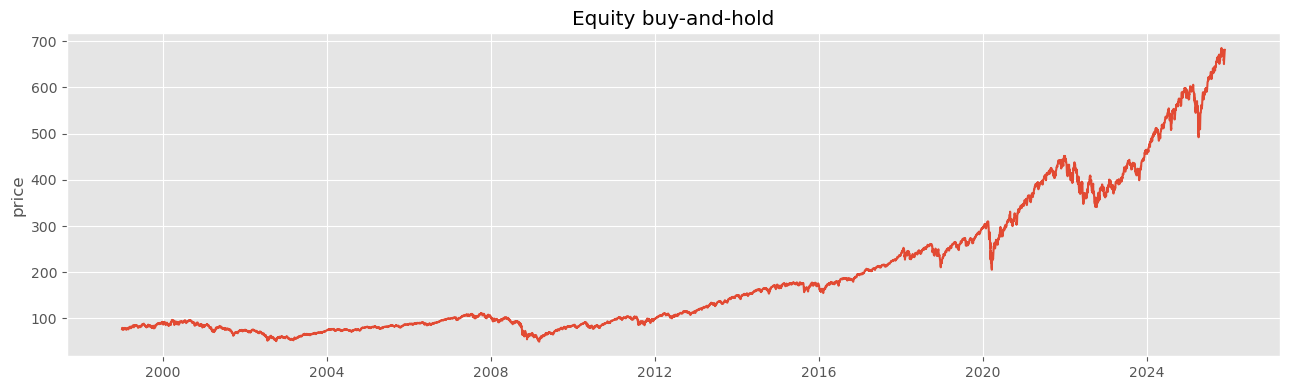

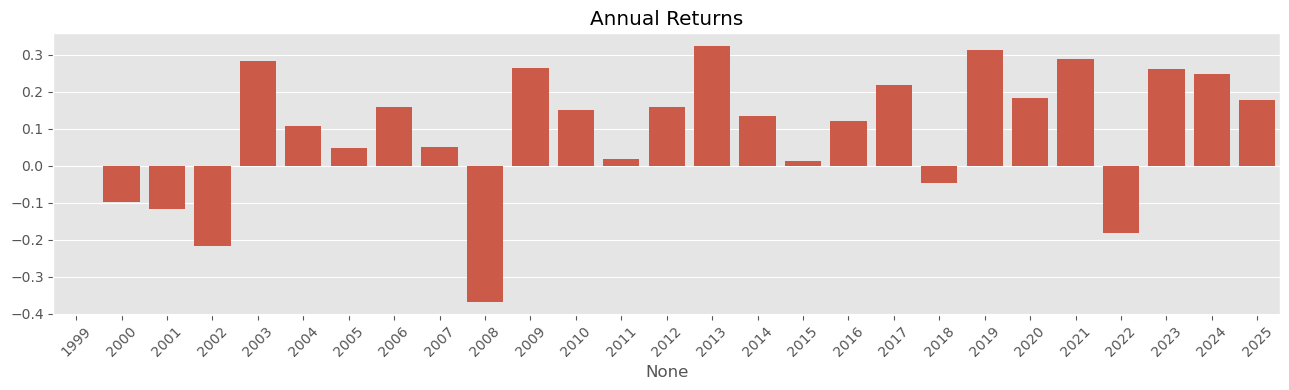

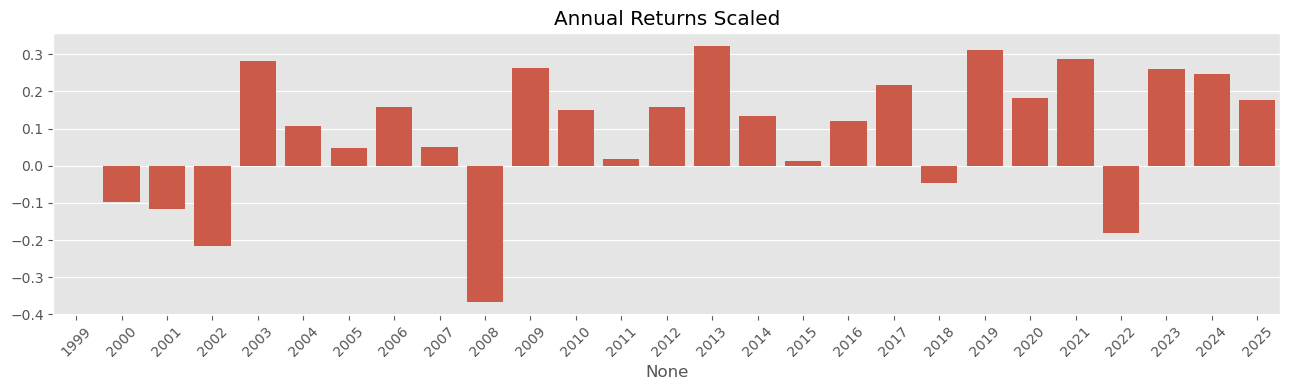

In [46]:
compute_metrics(df_eq.price, 'Equity buy-and-hold')

## 2. Equity–bond buy-and-hold

## 3. Volatility-driven equity-to-bond switching

max drawdown: -32.25%
win/loss ratio: 1.32
sharpe ratio: 0.41
annualized return: 3.97%
multiplier: 1.71
annualized return scaled: 6.47%


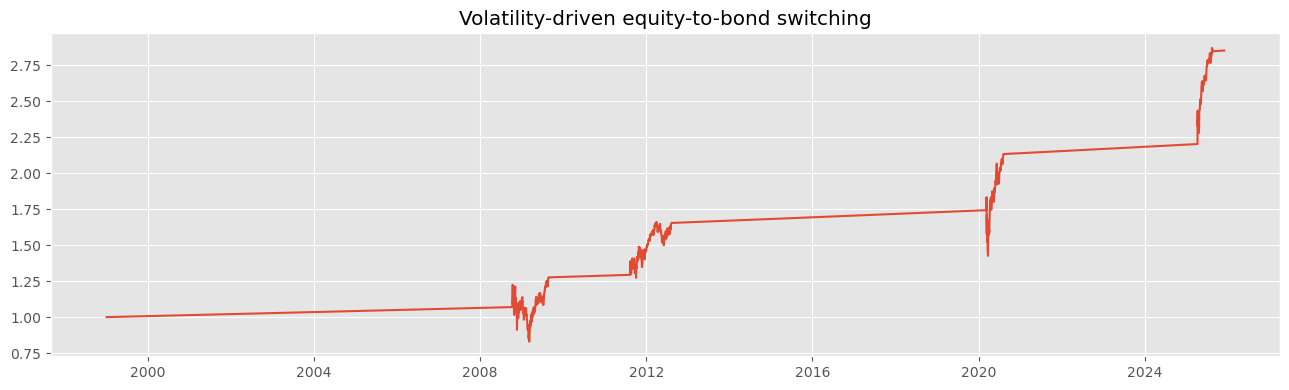

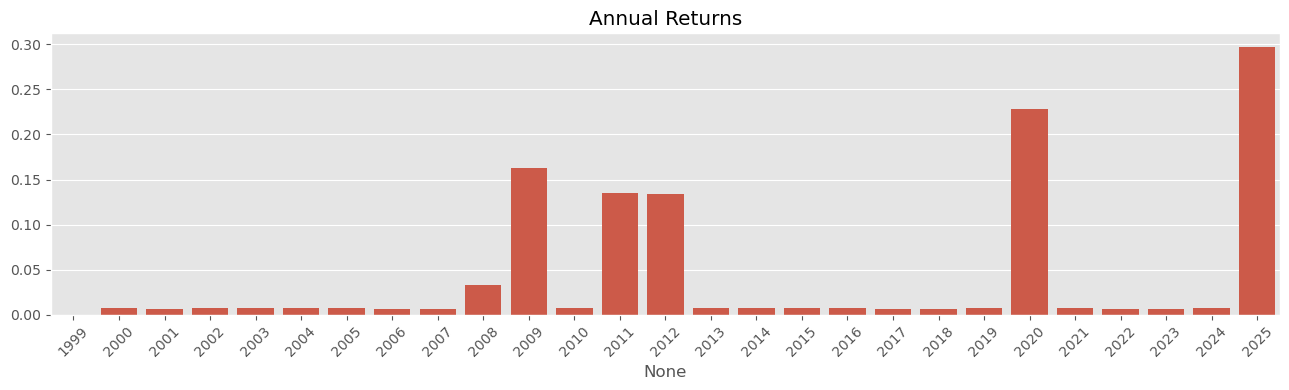

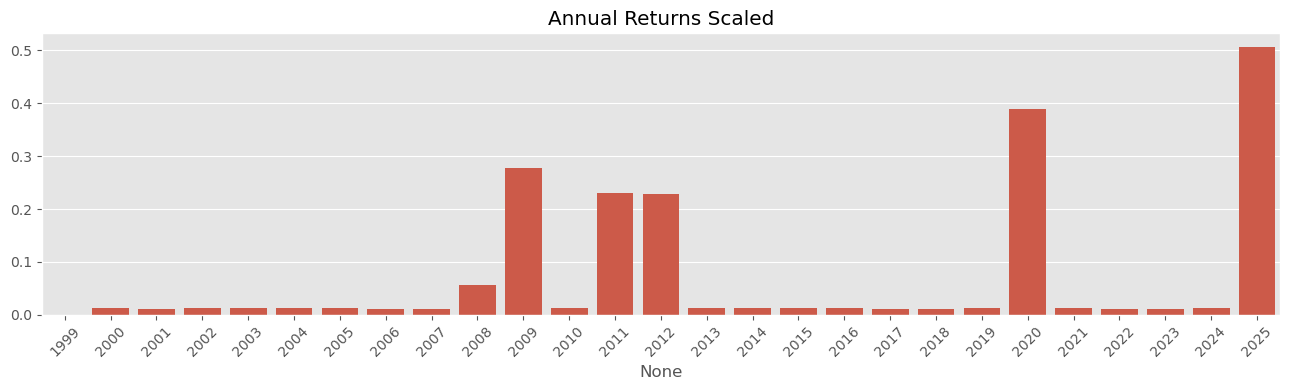

In [47]:
df_vol = df_price.pct_change().rolling(window=vol_window).std() * np.sqrt(252)
df_signal = pd.DataFrame(index=df_price.index, columns=df_price.columns, dtype=float)
df_signal.loc[df_vol.equity > vol_threshold_buy, 'equity'] = 1
df_signal.loc[df_vol.equity < vol_threshold_sell, 'equity'] = 0
df_signal = df_signal.ffill()
df_signal.loc[:, 'equity'] = df_signal.equity.fillna(0)
df_signal.loc[df_signal.equity == 0, 'bond'] = 1
df_signal.loc[df_signal.equity == 1, 'bond'] = 0
portfolio_level = df_price.pct_change().multiply(df_signal).sum(axis=1).add(1).cumprod()
compute_metrics(portfolio_level, 'Volatility-driven equity-to-bond switching')

## 4. Drawdown-driven equity-to-bond switching

max drawdown: -32.25%
win/loss ratio: 1.14
sharpe ratio: 0.39
annualized return: 4.07%
multiplier: 1.71
annualized return scaled: 6.62%


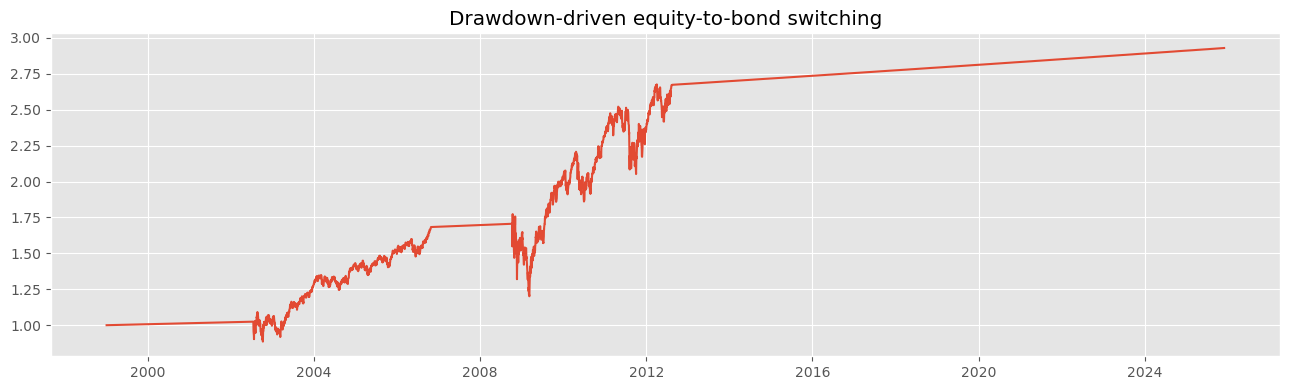

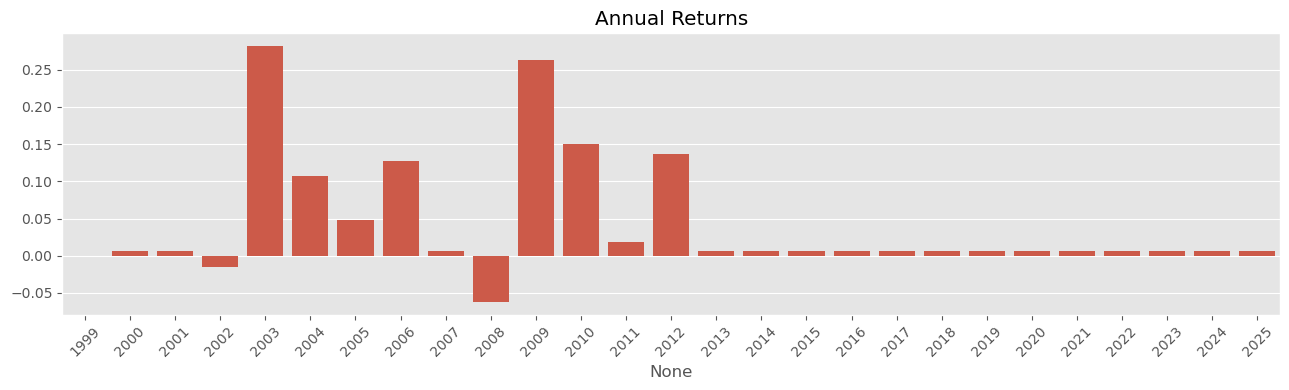

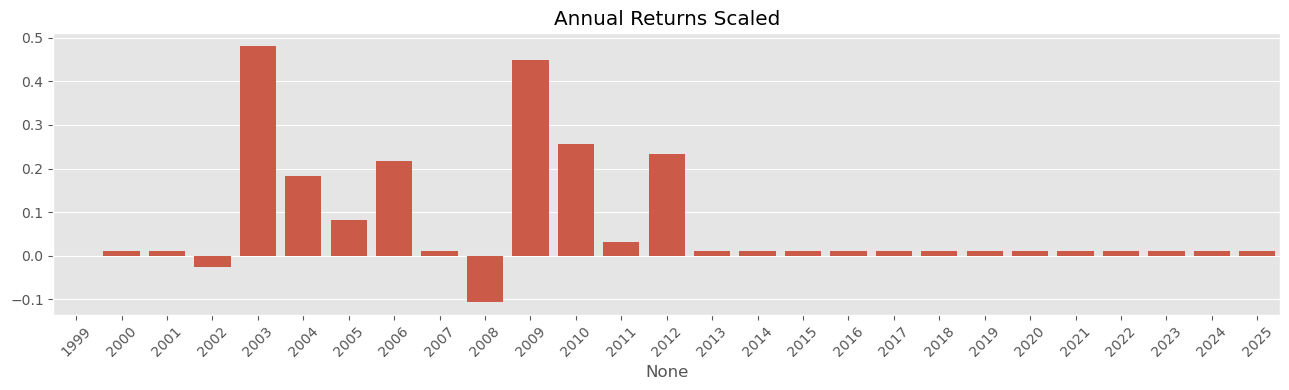

In [48]:
dd = df_price.equity / df_price.equity.expanding().max()
df_signal = pd.DataFrame(index=df_price.index, columns=df_price.columns, dtype=float)
df_signal.loc[dd < dd_threshold_buy, 'equity'] = 1
df_signal.loc[dd >= dd_threshold_sell, 'equity'] = 0
df_signal = df_signal.ffill()
df_signal.loc[:, 'equity'] = df_signal.equity.fillna(0)
df_signal.loc[df_signal.equity == 0, 'bond'] = 1
df_signal.loc[df_signal.equity == 1, 'bond'] = 0
portfolio_level = df_price.pct_change().multiply(df_signal).sum(axis=1).add(1).cumprod()
compute_metrics(portfolio_level, 'Drawdown-driven equity-to-bond switching')

## 5. Drawdown-driven & volatility-driven equity-to-bond switching

max drawdown: -32.25%
win/loss ratio: 1.20
sharpe ratio: 0.48
annualized return: 5.67%
multiplier: 1.71
annualized return scaled: 9.23%


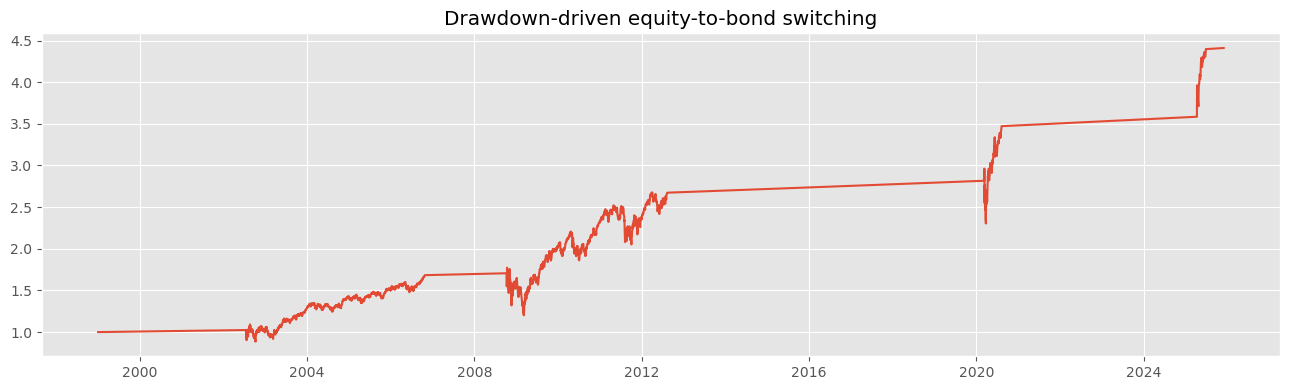

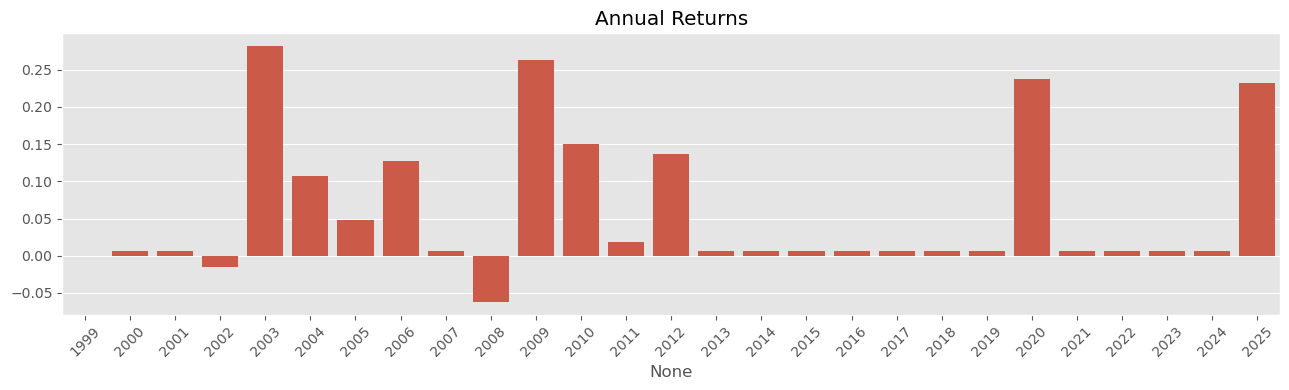

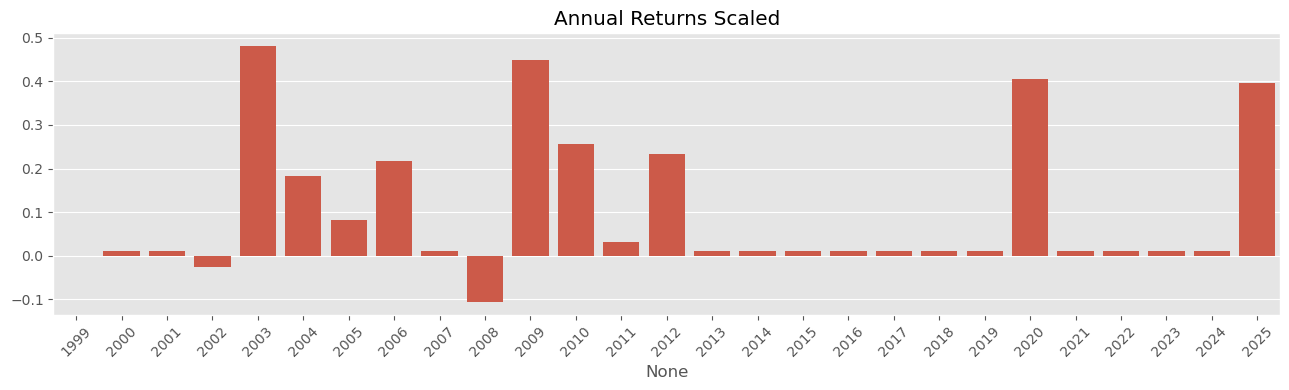

In [49]:
dd = df_price.equity / df_price.equity.expanding().max()
df_signal = pd.DataFrame(index=df_price.index, columns=df_price.columns, dtype=float)
df_signal.loc[df_vol.equity > vol_threshold_buy, 'equity'] = 1
df_signal.loc[dd < dd_threshold_buy, 'equity'] = 1
df_signal.loc[dd >= dd_threshold_sell, 'equity'] = 0
df_signal = df_signal.ffill()
df_signal.loc[:, 'equity'] = df_signal.equity.fillna(0)
df_signal.loc[df_signal.equity == 0, 'bond'] = 1
df_signal.loc[df_signal.equity == 1, 'bond'] = 0
portfolio_level = df_price.pct_change().multiply(df_signal).sum(axis=1).add(1).cumprod()
compute_metrics(portfolio_level, 'Drawdown-driven equity-to-bond switching')